In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [27]:
import kagglehub
import os

path = kagglehub.dataset_download(
    "muhammadshahidazeem/customer-churn-dataset"
)

print(path)
print(os.listdir(path))

Using Colab cache for faster access to the 'customer-churn-dataset' dataset.
/kaggle/input/customer-churn-dataset
['customer_churn_dataset-testing-master.csv', 'customer_churn_dataset-training-master.csv']


In [28]:
train = pd.read_csv(
    os.path.join(path, "customer_churn_dataset-training-master.csv")
)

test = pd.read_csv(
    os.path.join(path, "customer_churn_dataset-testing-master.csv")
)

In [29]:
print(train.shape)
print(test.shape)

train.head()

(440833, 12)
(64374, 12)


,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [30]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [31]:
train.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000,440832.000000
mean,225398.667955,39.373153,31.256336,15.807494,3.604437,12.965722,631.616223,14.480868,0.567107
std,129531.918550,12.442369,17.255727,8.586242,3.070218,8.258063,240.803001,8.596208,0.495477
min,2.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,113621.750000,29.000000,16.000000,9.000000,1.000000,6.000000,480.000000,7.000000,0.000000
50%,226125.500000,39.000000,32.000000,16.000000,3.000000,12.000000,661.000000,14.000000,1.000000
75%,337739.250000,48.000000,46.000000,23.000000,6.000000,19.000000,830.000000,22.000000,1.000000
max,449999.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


In [32]:
train.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Tenure',
 'Usage Frequency',
 'Support Calls',
 'Payment Delay',
 'Subscription Type',
 'Contract Length',
 'Total Spend',
 'Last Interaction',
 'Churn']

In [33]:
train.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [34]:
train.duplicated().sum()

np.int64(0)

In [35]:
train["Churn"].value_counts(normalize=True)

,proportion
Churn,
1.0,0.567107
0.0,0.432893


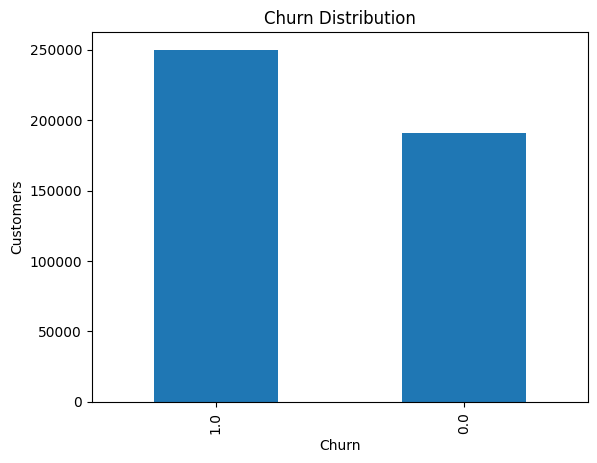

In [36]:
train["Churn"].value_counts().plot(kind="bar")

plt.xlabel("Churn")
plt.ylabel("Customers")
plt.title("Churn Distribution")
plt.show()

In [37]:
X_train = train.drop(
    columns=["CustomerID", "Churn"]
)

y_train = train["Churn"]

X_test = test.drop(
    columns=["CustomerID", "Churn"]
)

y_test = test["Churn"]

In [38]:
categorical_features = X_train.select_dtypes(
    include="object"
).columns.tolist()

numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

print("Categorical:")
print(categorical_features)

print("\nNumerical:")
print(numerical_features)

Categorical:
['Gender', 'Subscription Type', 'Contract Length']

Numerical:
['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction']


In [39]:
for col in numerical_features:
    median = X_train[col].median()

    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)

In [40]:
for col in categorical_features:
    mode = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(mode)
    X_test[col] = X_test[col].fillna(mode)

In [41]:
print(X_train.isnull().sum().sum())
print(X_test.isnull().sum().sum())

0
0


In [42]:
X_train = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

In [43]:
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

In [44]:
from sklearn.ensemble import RandomForestClassifier


valid_indices = y_train.dropna().index
X_train = X_train.loc[valid_indices]
y_train = y_train.loc[valid_indices]

baseline_model = RandomForestClassifier(
    random_state=42
)

baseline_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
y_pred_baseline = baseline_model.predict(X_test)

In [46]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Baseline Random Forest")

print("Accuracy:",
      accuracy_score(y_test, y_pred_baseline))

print("Precision:",
      precision_score(y_test, y_pred_baseline))

print("Recall:",
      recall_score(y_test, y_pred_baseline))

print("F1 Score:",
      f1_score(y_test, y_pred_baseline))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_baseline))

Baseline Random Forest
Accuracy: 0.503464131481654
Precision: 0.4882076606115021
Recall: 0.9985898402912143
F1 Score: 0.6557977257064094

Confusion Matrix:
[[ 1960 31921]
 [   43 30450]]


In [47]:
from sklearn.model_selection import RandomizedSearchCV

In [48]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [49]:
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_grid,
    n_iter=15,
    scoring="f1",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

In [51]:
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   random_state=42, scoring='f1', verbose=1)

In [52]:
print("Best Parameters:")
print(random_search.best_params_)

print("\nBest CV F1 Score:")
print(random_search.best_score_)

Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

Best CV F1 Score:
0.9995638155364421


In [53]:
optimized_model = random_search.best_estimator_

In [54]:
y_pred_optimized = optimized_model.predict(X_test)

In [55]:
print("Optimized Random Forest")

print("Accuracy:",
      accuracy_score(y_test, y_pred_optimized))

print("Precision:",
      precision_score(y_test, y_pred_optimized))

print("Recall:",
      recall_score(y_test, y_pred_optimized))

print("F1 Score:",
      f1_score(y_test, y_pred_optimized))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_optimized))

Optimized Random Forest
Accuracy: 0.5034485972597632
Precision: 0.48819945486612154
Recall: 0.9985570458793821
F1 Score: 0.6557832505949625

Confusion Matrix:
[[ 1960 31921]
 [   44 30449]]


In [56]:
results = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Optimized Random Forest"
    ],

    "Accuracy": [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_optimized)
    ],

    "Precision": [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_optimized)
    ],

    "Recall": [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_optimized)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_optimized)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline Random Forest,0.5035,0.4882,0.9986,0.6558
1,Optimized Random Forest,0.5034,0.4882,0.9986,0.6558


In [57]:
print(random_search.best_params_)


{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [58]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": optimized_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,Support Calls,0.304152
5,Total Spend,0.210899
0,Age,0.138944
10,Contract Length_Monthly,0.127878
4,Payment Delay,0.124604
6,Last Interaction,0.039200
7,Gender_Male,0.034137
1,Tenure,0.009276
11,Contract Length_Quarterly,0.005549
2,Usage Frequency,0.003427


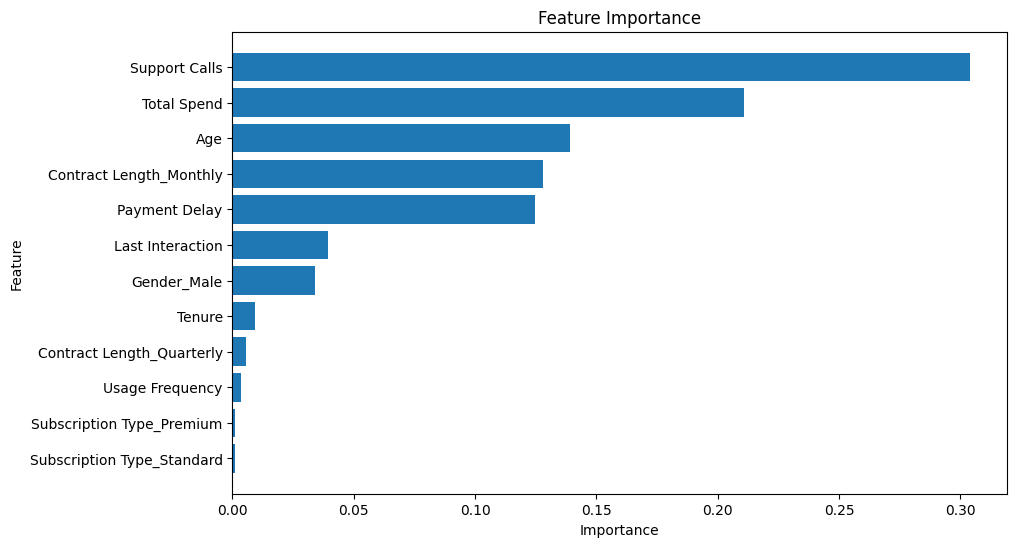

In [60]:
importance.round(4)
plt.figure(figsize=(10, 6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()
plt.show()